# 06 - Final report

Joins the four metric CSVs into one frame, reports the headline numbers per matrix cell and the stratified views (by difficulty and by SQL feature), renders the per-target figures, lists the failures for the error-taxonomy annotation, and writes the consolidated `eval/reports/final.md`. This is the synthesis the thesis results chapter mirrors section for section. Targets are never averaged together; every table and figure is per target, with models in the canonical order `llama3.2`, `qwen3-coder`, `gemma4`, `opus-4-8`, `opus-4-8-thinking`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "eval"))

from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
from harness import (
    FIGURES_DIR,
    FINAL_REPORT_MD,
    METRICS_BEHAVIOURAL_CSV,
    METRICS_DISTANCE_CSV,
    METRICS_EXECUTION_CSV,
    METRICS_STRUCTURAL_CSV,
    frames,
    plots,
    report,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Load and join metric CSVs

Outer-merge behavioural, structural, and distance on the stratification keys; left-merge the execution columns when notebook 05 has produced them (a run without databases still reports the DB-free metrics).

In [2]:
df, HAS_EXEC = report.join_metric_csvs(
    METRICS_BEHAVIOURAL_CSV, METRICS_STRUCTURAL_CSV, METRICS_DISTANCE_CSV, METRICS_EXECUTION_CSV
)
print(f"Joined rows: {len(df)}")
df.head()

Joined rows: 225


,dataset,target,model,provider,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,...,reference_error,translated_runtime_s,execution_error,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,reference_rows,translated_rows
0,ldbc,aql,claude-opus-4-8,anthropic,ldbc_q01,easy,True,True,1,3.278285,...,NaN,0.007408,NaN,1.0,1.0,1.0,1.0,0.0,1,1
1,ldbc,aql,claude-opus-4-8,anthropic,ldbc_q02,easy,True,True,1,2.613209,...,NaN,0.133319,NaN,1.0,1.0,1.0,1.0,0.0,12932,12932
2,ldbc,aql,claude-opus-4-8,anthropic,ldbc_q03,easy,True,True,1,4.596436,...,NaN,0.005769,NaN,1.0,1.0,1.0,1.0,0.0,4,4
3,ldbc,aql,claude-opus-4-8,anthropic,ldbc_q04,hard,True,True,1,2.334190,...,NaN,15.476401,NaN,1.0,1.0,1.0,1.0,0.0,10,10
4,ldbc,aql,claude-opus-4-8,anthropic,ldbc_q05,hard,True,True,1,3.771293,...,NaN,118.041009,NaN,1.0,1.0,1.0,1.0,0.0,20,20


## Helper methods

Derive the shared axes (models in canonical order, queries, targets present), the by-feature roll-up, and the per-target table builders that assemble the markdown report. Nothing is hardcoded: models, queries, and targets come from the data.

In [3]:
df = frames.order_frame_models(df)
MODELS = plots.model_axis(df)
QUERIES = plots.query_axis(df)
TARGETS = [t for t in ["cypher", "aql", "gremlin"] if t in set(df["target"])]
FEATURES = frames.feature_map("ldbc")
print(f"{len(MODELS)} model(s): {MODELS}")
print(f"{len(QUERIES)} query id(s); targets in report: {TARGETS}; execution metrics present: {HAS_EXEC}")

5 model(s): ['llama3.2:latest', 'qwen3-coder:30b', 'gemma4:26b', 'claude-opus-4-8', 'claude-opus-4-8-thinking']
15 query id(s); targets in report: ['cypher', 'aql', 'gremlin']; execution metrics present: True


In [4]:
# The table/section builders live in harness.report; PRIMARY and a thin _headline wrapper are
# all the notebook needs so the per-target display cells below stay display(_headline(sub)).
PRIMARY = report.primary_cols(HAS_EXEC)


def _headline(sub):
    """Per-model headline table for one target (thin wrapper over harness.report)."""
    return report.headline(sub, HAS_EXEC)

## Prerequisites

The four metric CSVs from notebooks 02 to 05 must exist (execution optional). The join above already loaded them; confirm coverage.

In [5]:
print(
    f"Joined {len(df)} record rows across "
    f"{df.groupby(['target', 'model'], observed=True).ngroups} matrix cells "
    f"({df['target'].nunique()} targets x {df['model'].nunique()} models); execution metrics: {HAS_EXEC}"
)

Joined 225 record rows across 15 matrix cells (3 targets x 5 models); execution metrics: True


## SQL to Cypher

### Headline (per model)

In [6]:
display(_headline(df[df["target"] == 'cypher']))

,validation_pass_rate,pass@1,component_f1,normalized_ted,execution_accuracy,result_f1
model,,,,,,
llama3.2:latest,1.0,0.866667,0.823287,0.404789,0.200000,0.208120
qwen3-coder:30b,1.0,1.000000,0.925120,0.210969,0.533333,0.563676
gemma4:26b,1.0,1.000000,0.981477,0.050576,1.000000,1.000000
claude-opus-4-8,1.0,1.000000,0.980390,0.066173,1.000000,1.000000
claude-opus-4-8-thinking,1.0,1.000000,0.971161,0.081915,1.000000,1.000000


### Figures

In [7]:
sub = df[df["target"] == 'cypher']
label = 'SQL -> Cypher'
prefix = 'cypher'

#### Per-model headline metrics

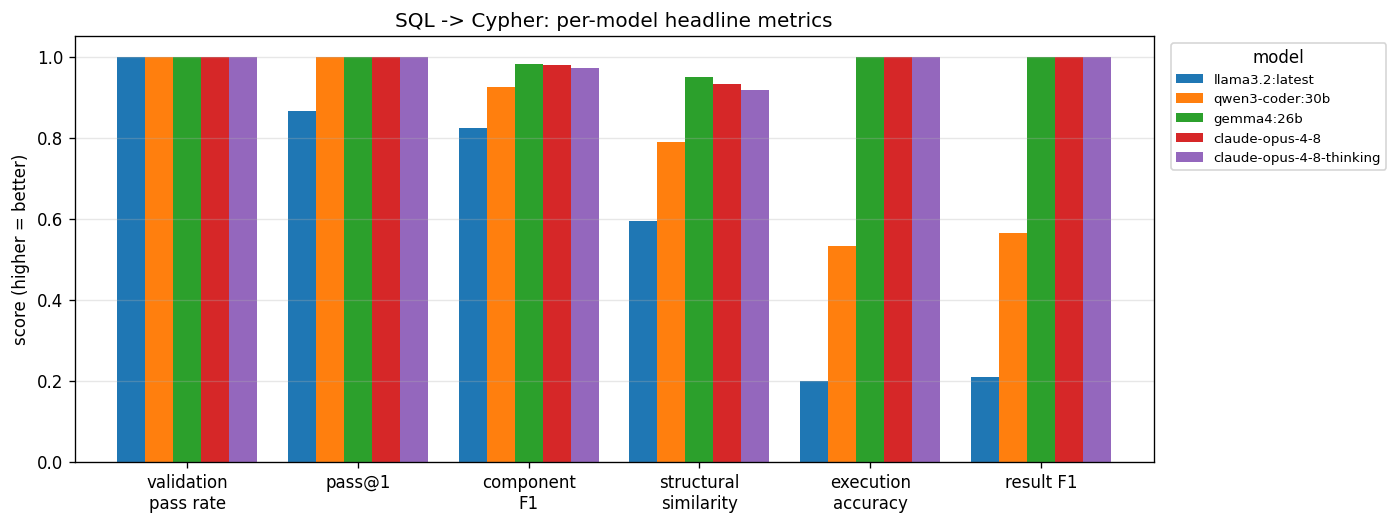

In [8]:
p = FIGURES_DIR / f"{prefix}_model_headline.png"
plots.headline_bars(sub, p, title=f"{label}: per-model headline metrics")
plots.show(p)
plt.close("all")

#### Pass / fail by query x model

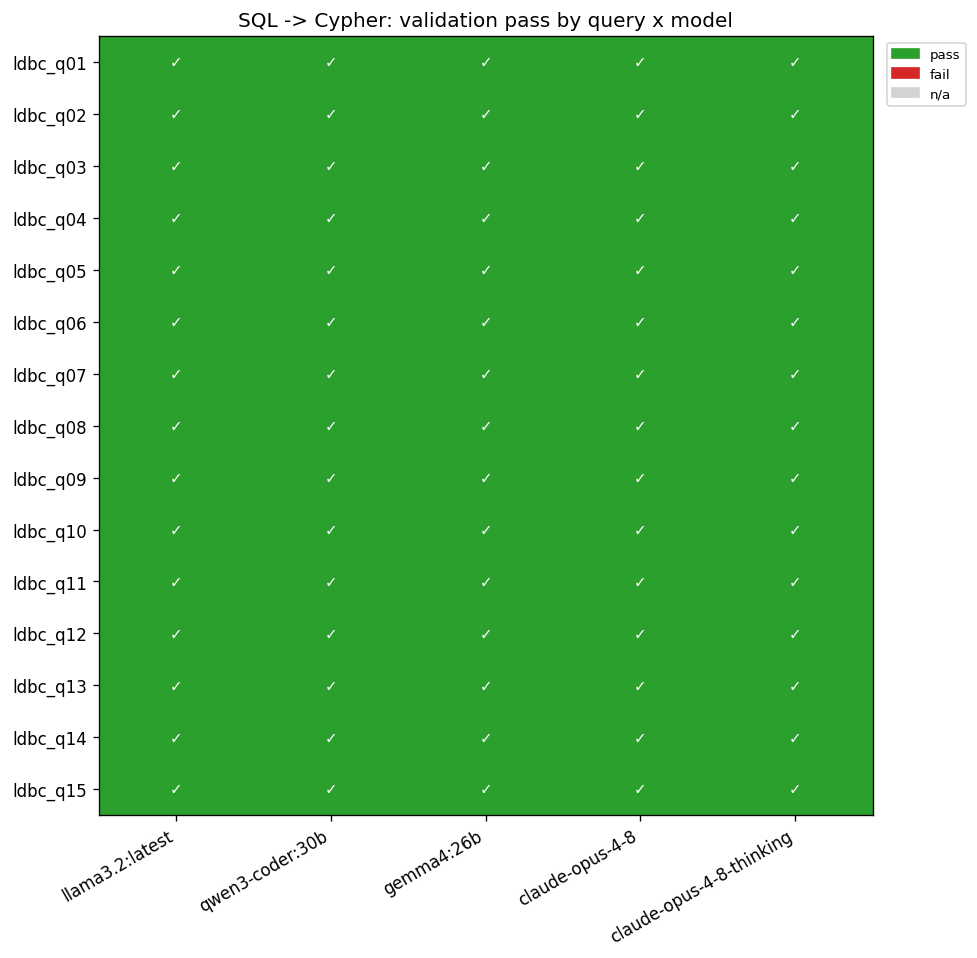

In [9]:
p = FIGURES_DIR / f"{prefix}_query_model_pass.png"
plots.query_model_heatmap(sub, "validation_passed", p, discrete=True, title=f"{label}: validation pass by query x model", cbar_label="pass")
plots.show(p)
plt.close("all")

#### Component F1 by query x model

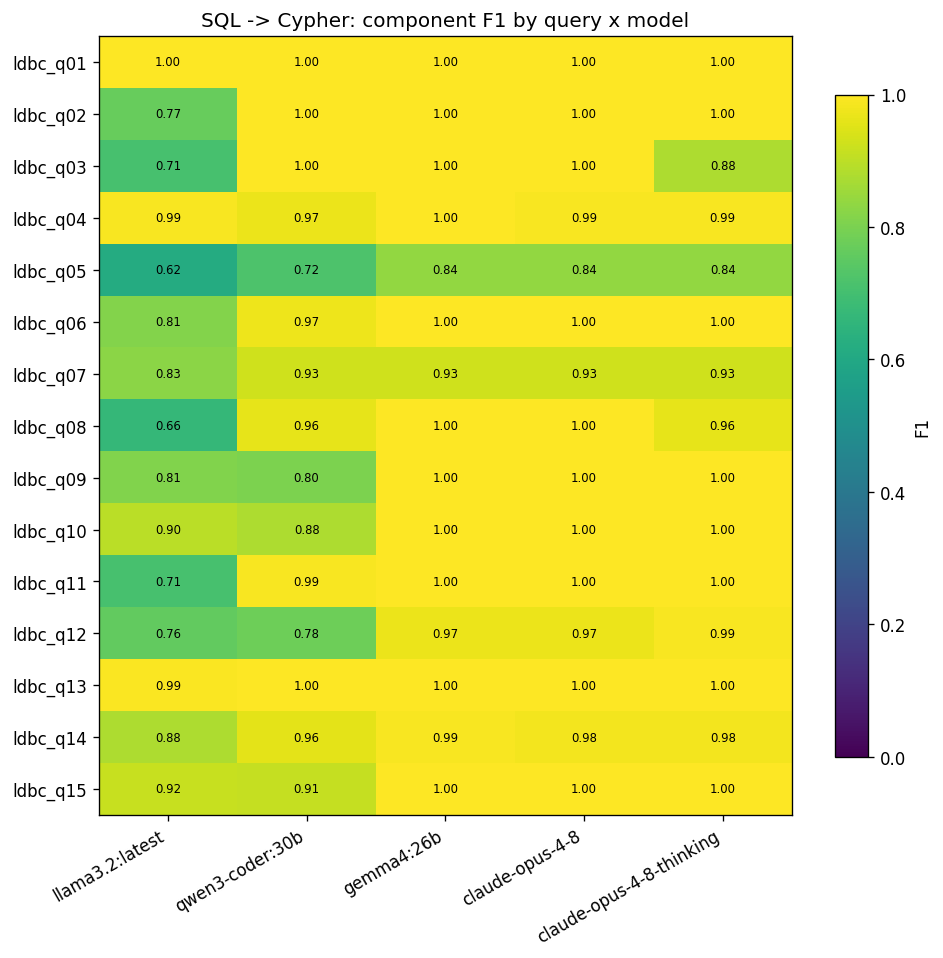

In [10]:
p = FIGURES_DIR / f"{prefix}_query_model_f1.png"
plots.query_model_heatmap(sub, "component_f1_overall", p, title=f"{label}: component F1 by query x model", cbar_label="F1")
plots.show(p)
plt.close("all")

#### Execution accuracy by query x model

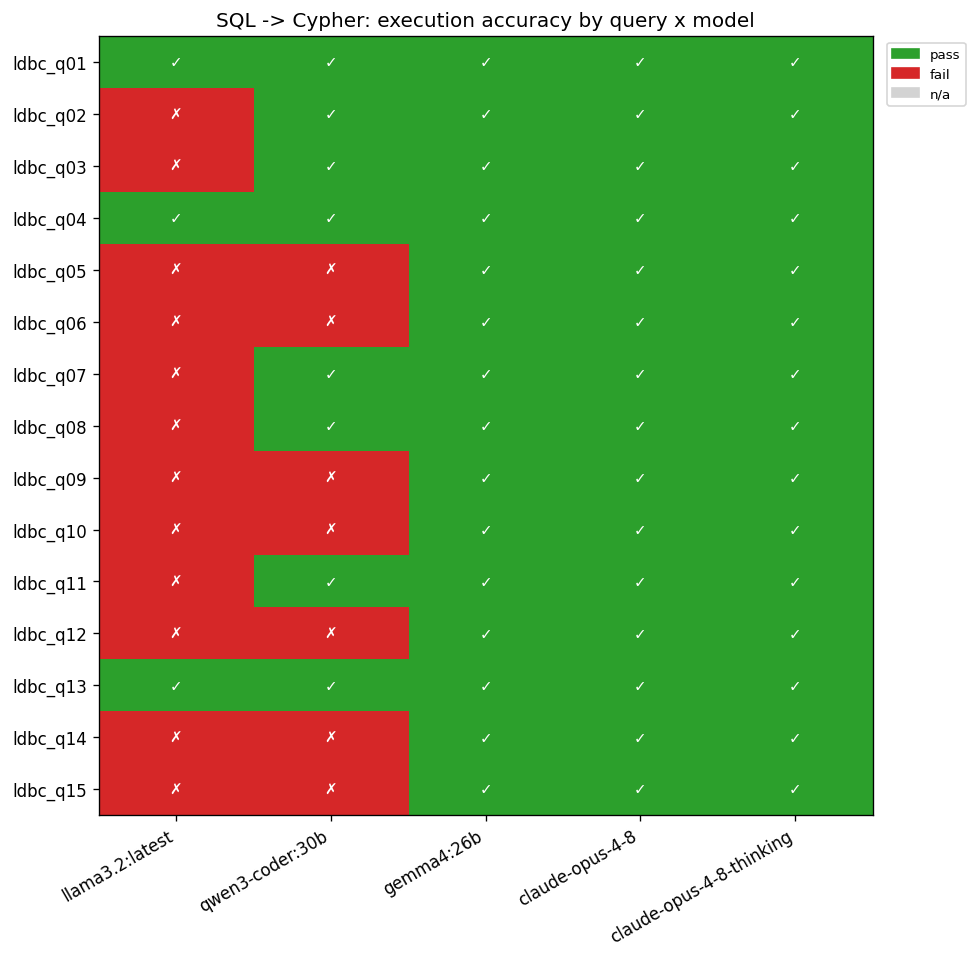

In [11]:
p = FIGURES_DIR / f"{prefix}_query_model_exec.png"
plots.query_model_heatmap(sub, "execution_accuracy", p, discrete=True, title=f"{label}: execution accuracy by query x model", cbar_label="exec acc")
plots.show(p)
plt.close("all")

#### Component F1 per model

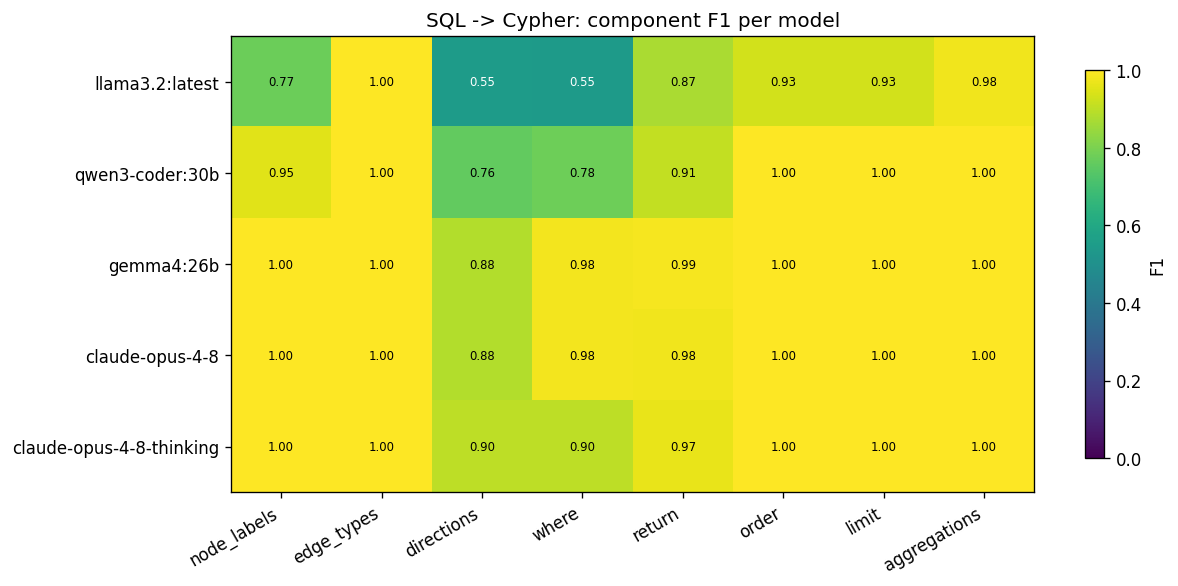

In [12]:
p = FIGURES_DIR / f"{prefix}_component_f1.png"
plots.component_f1_by_model(sub, path=p, title=f"{label}: component F1 per model")
plots.show(p)
plt.close("all")

#### Normalised TED by query x model (lower is better)

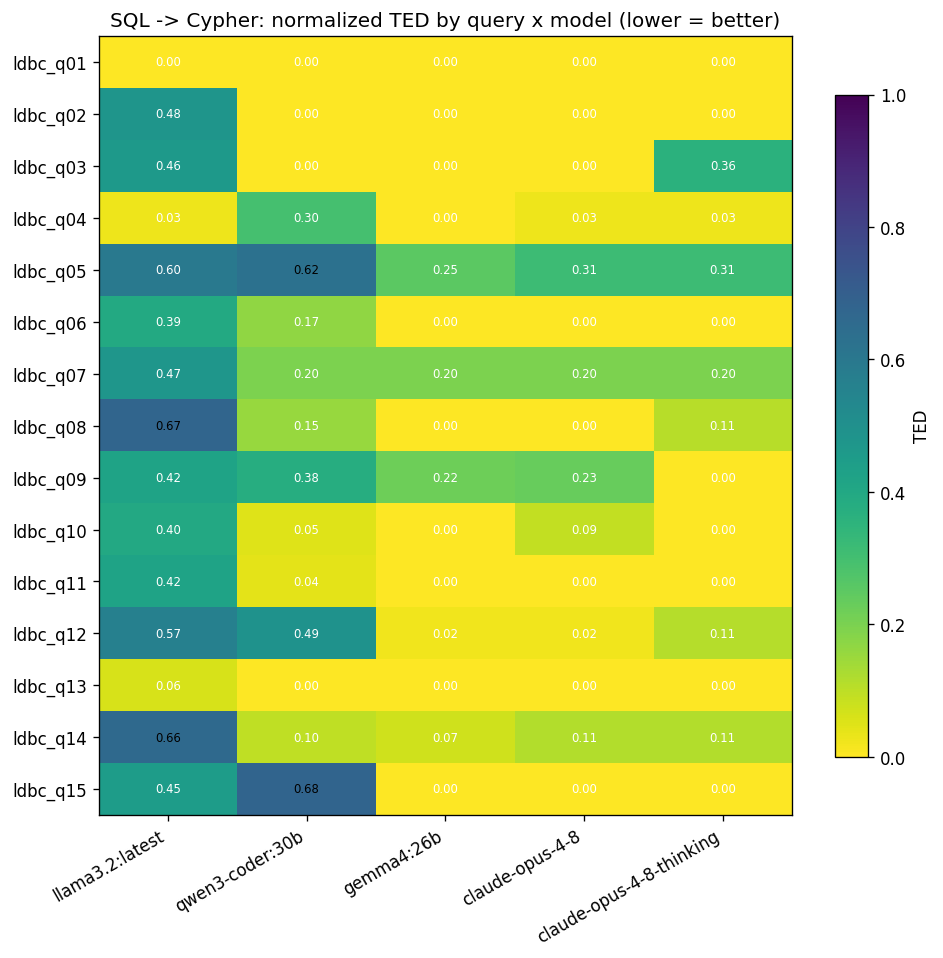

In [13]:
p = FIGURES_DIR / f"{prefix}_query_model_ted.png"
plots.query_model_heatmap(sub, "normalized_ted", p, cmap_name="viridis_r", title=f"{label}: normalized TED by query x model (lower = better)", cbar_label="TED")
plots.show(p)
plt.close("all")

#### Cost and latency per model

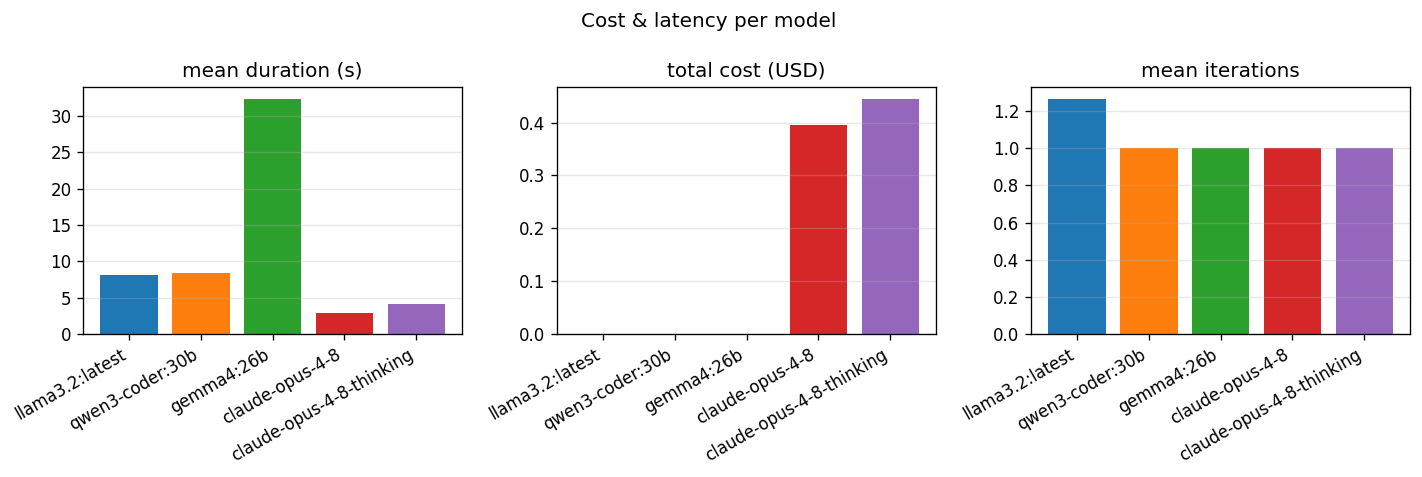

In [14]:
p = FIGURES_DIR / f"{prefix}_cost_latency.png"
plots.cost_latency(sub, p)
plots.show(p)
plt.close("all")

#### Pass@1 by difficulty

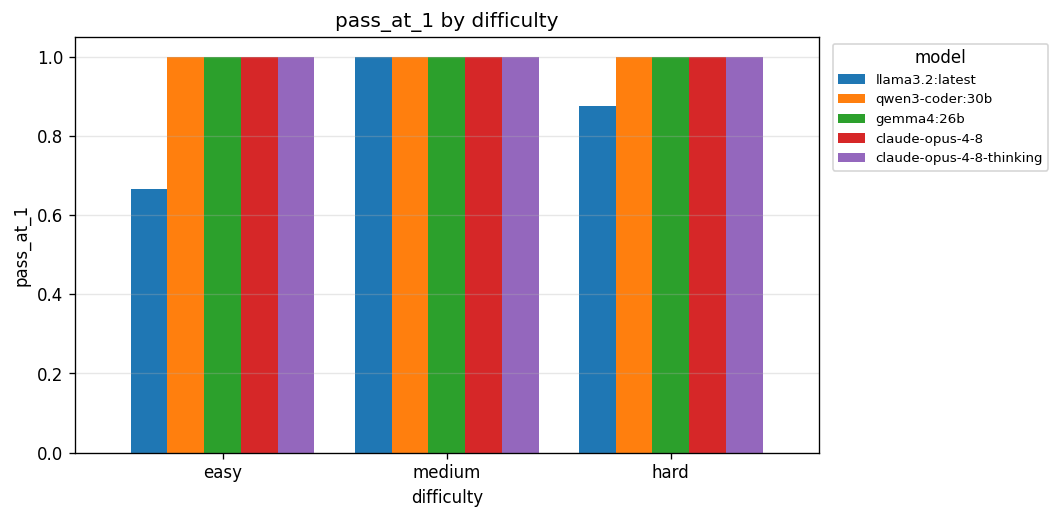

In [15]:
p = FIGURES_DIR / f"{prefix}_passrate_by_difficulty.png"
plots.passrate_by_difficulty(sub, "pass_at_1", p)
plots.show(p)
plt.close("all")

## SQL to AQL

### Headline (per model)

In [16]:
display(_headline(df[df["target"] == 'aql']))

,validation_pass_rate,pass@1,component_f1,normalized_ted,execution_accuracy,result_f1
model,,,,,,
llama3.2:latest,0.8,0.466667,0.547494,0.414359,0.000000,0.000000
qwen3-coder:30b,1.0,1.000000,0.821752,0.325791,0.466667,0.466667
gemma4:26b,1.0,0.933333,0.875839,0.226171,0.933333,0.933333
claude-opus-4-8,1.0,1.000000,0.883675,0.224506,0.933333,0.933333
claude-opus-4-8-thinking,1.0,1.000000,0.901117,0.191370,0.933333,0.933333


### Figures

In [17]:
sub = df[df["target"] == 'aql']
label = 'SQL -> AQL'
prefix = 'aql'

#### Per-model headline metrics

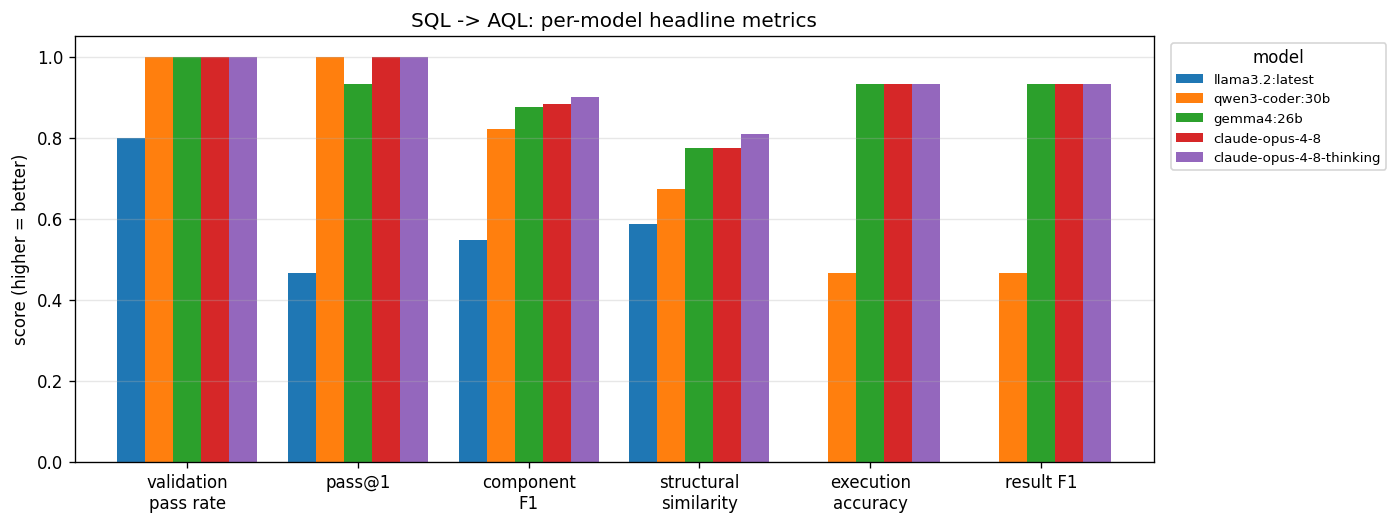

In [18]:
p = FIGURES_DIR / f"{prefix}_model_headline.png"
plots.headline_bars(sub, p, title=f"{label}: per-model headline metrics")
plots.show(p)
plt.close("all")

#### Pass / fail by query x model

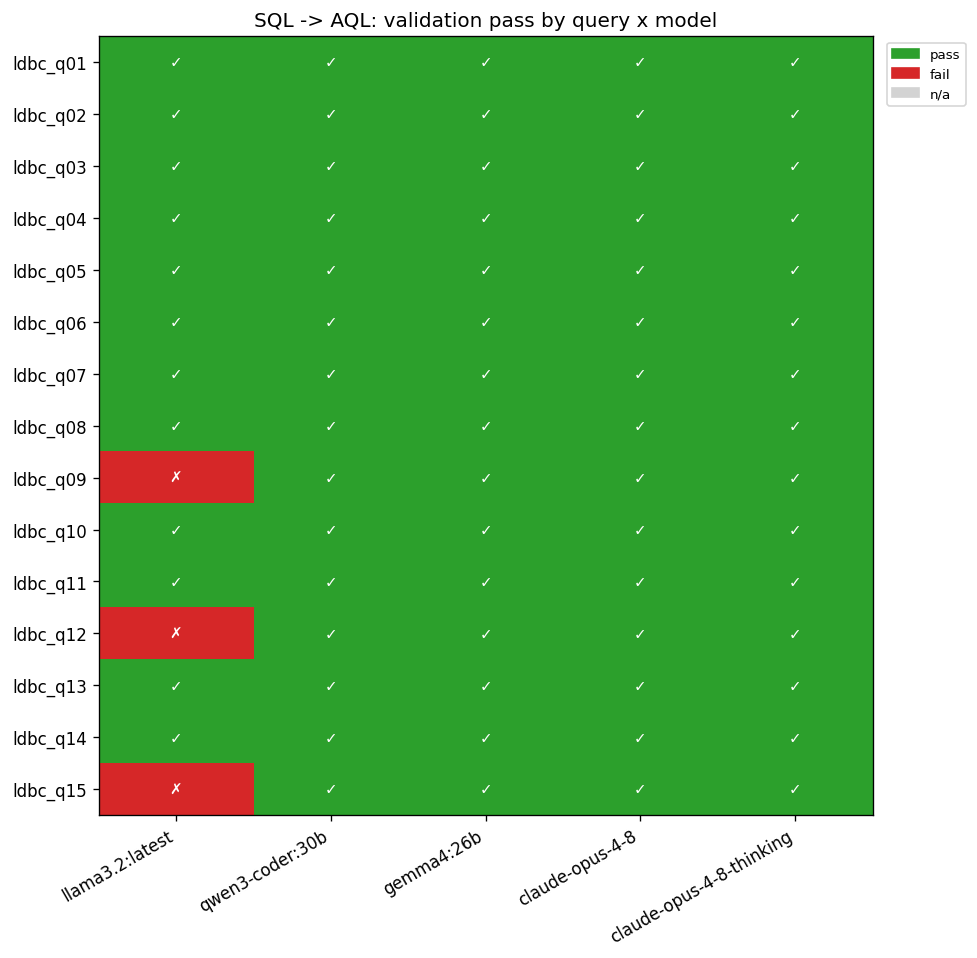

In [19]:
p = FIGURES_DIR / f"{prefix}_query_model_pass.png"
plots.query_model_heatmap(sub, "validation_passed", p, discrete=True, title=f"{label}: validation pass by query x model", cbar_label="pass")
plots.show(p)
plt.close("all")

#### Component F1 by query x model

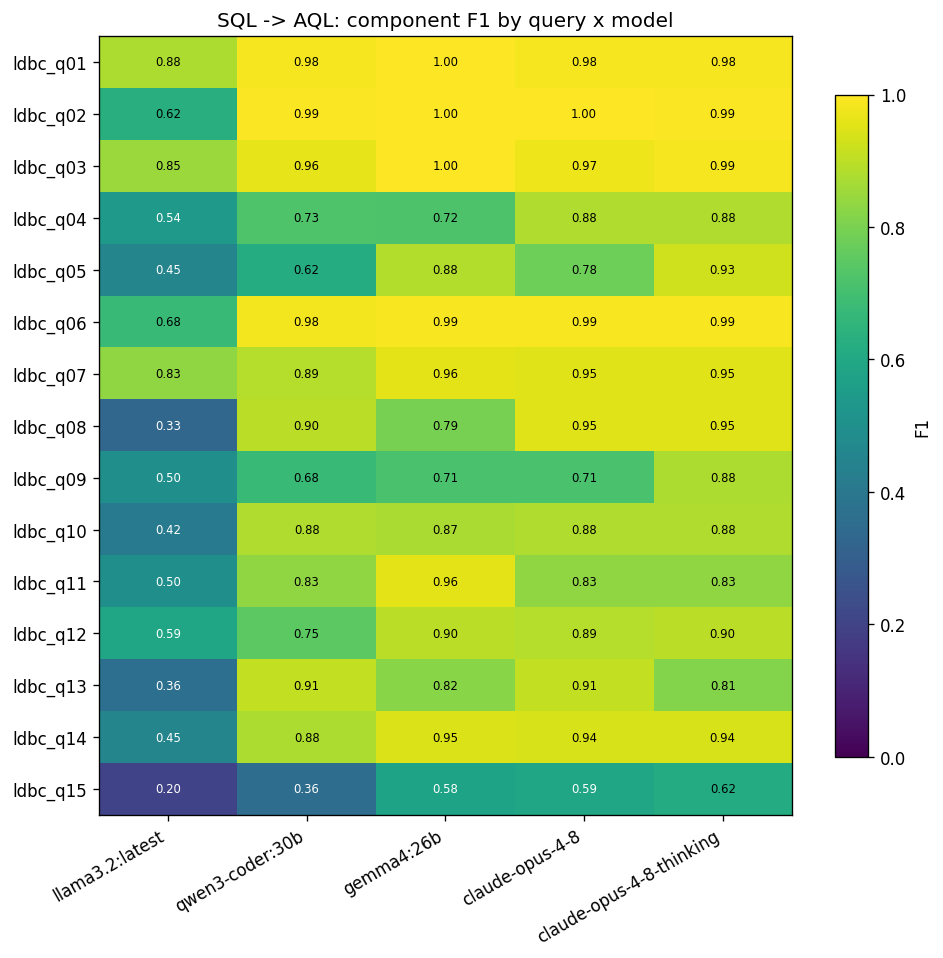

In [20]:
p = FIGURES_DIR / f"{prefix}_query_model_f1.png"
plots.query_model_heatmap(sub, "component_f1_overall", p, title=f"{label}: component F1 by query x model", cbar_label="F1")
plots.show(p)
plt.close("all")

#### Execution accuracy by query x model

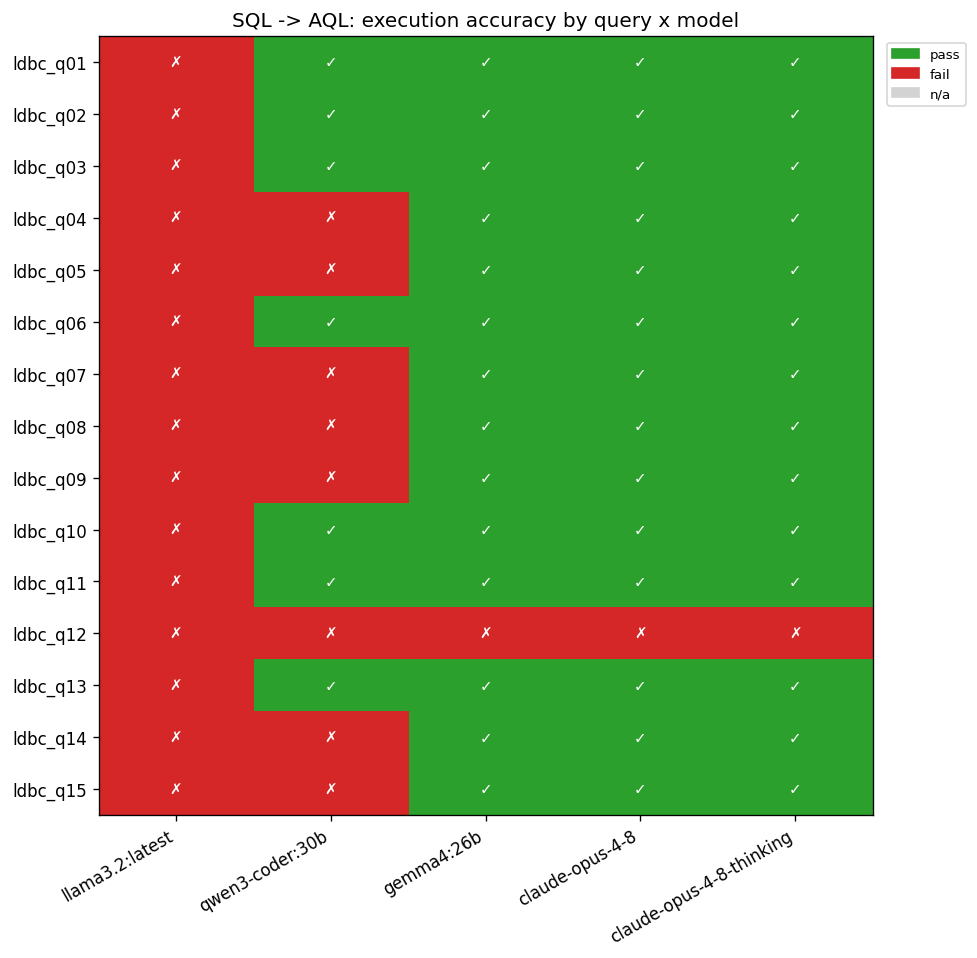

In [21]:
p = FIGURES_DIR / f"{prefix}_query_model_exec.png"
plots.query_model_heatmap(sub, "execution_accuracy", p, discrete=True, title=f"{label}: execution accuracy by query x model", cbar_label="exec acc")
plots.show(p)
plt.close("all")

#### Component F1 per model

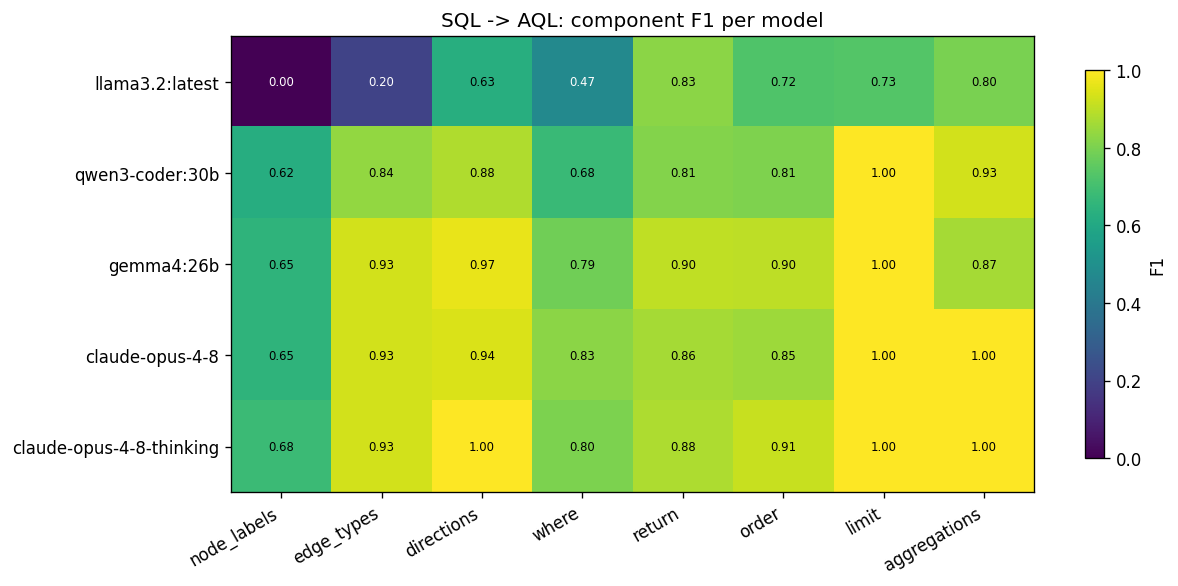

In [22]:
p = FIGURES_DIR / f"{prefix}_component_f1.png"
plots.component_f1_by_model(sub, path=p, title=f"{label}: component F1 per model")
plots.show(p)
plt.close("all")

#### Normalised TED by query x model (lower is better)

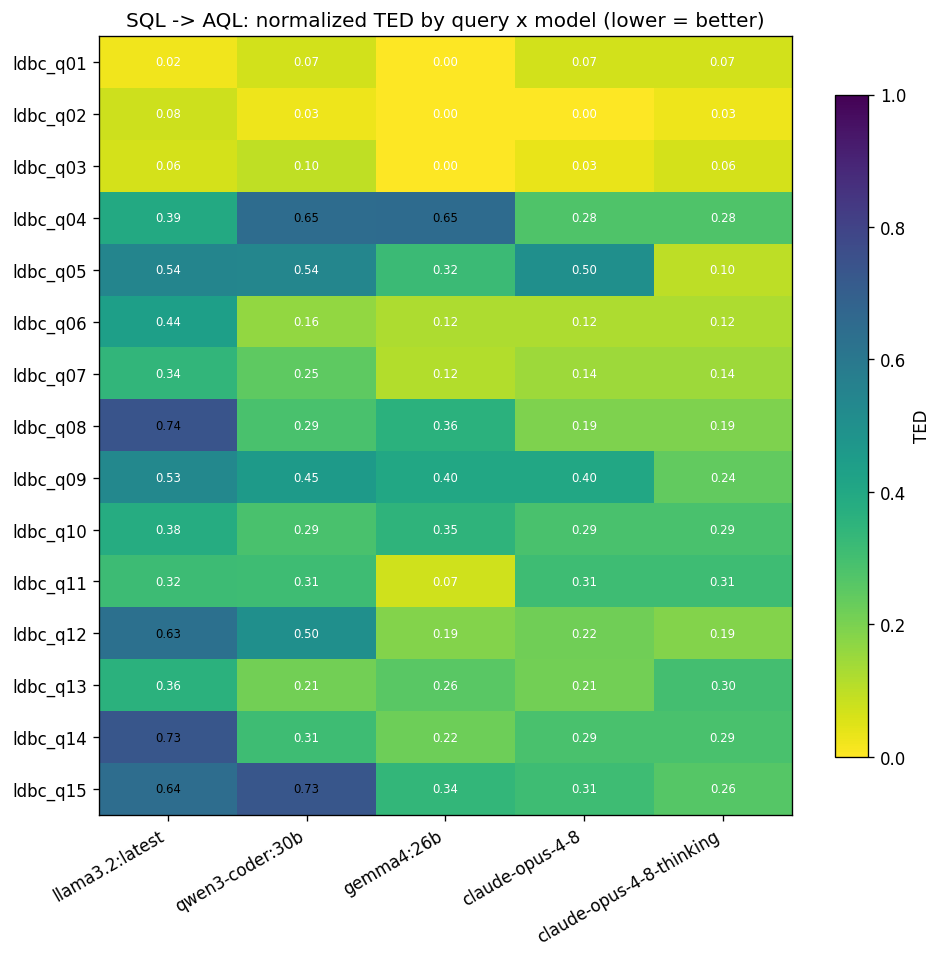

In [23]:
p = FIGURES_DIR / f"{prefix}_query_model_ted.png"
plots.query_model_heatmap(sub, "normalized_ted", p, cmap_name="viridis_r", title=f"{label}: normalized TED by query x model (lower = better)", cbar_label="TED")
plots.show(p)
plt.close("all")

#### Cost and latency per model

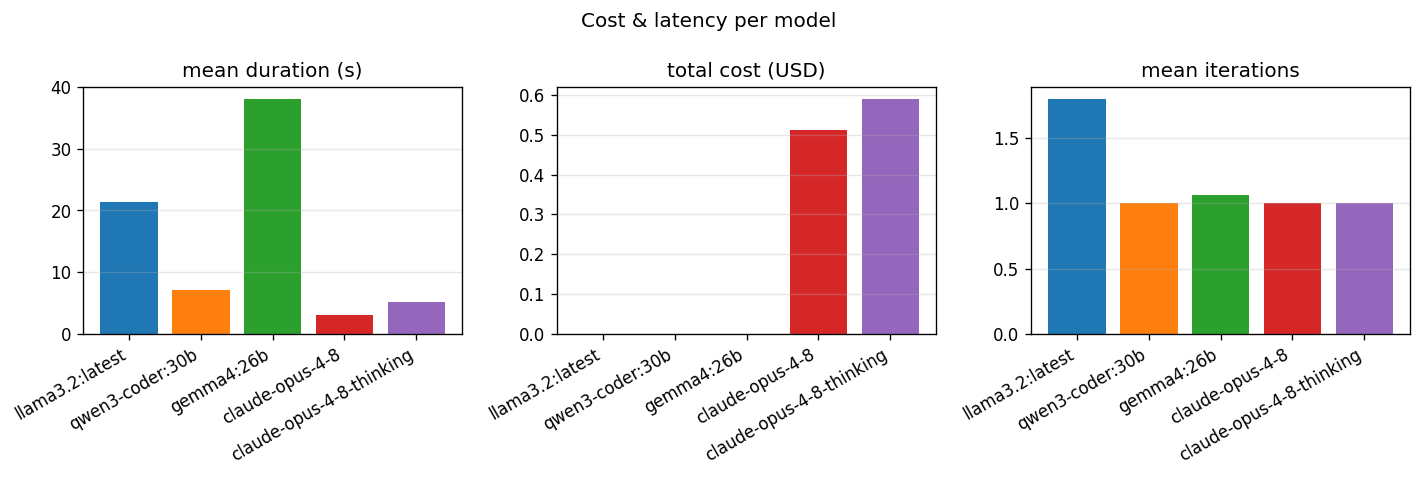

In [24]:
p = FIGURES_DIR / f"{prefix}_cost_latency.png"
plots.cost_latency(sub, p)
plots.show(p)
plt.close("all")

#### Pass@1 by difficulty

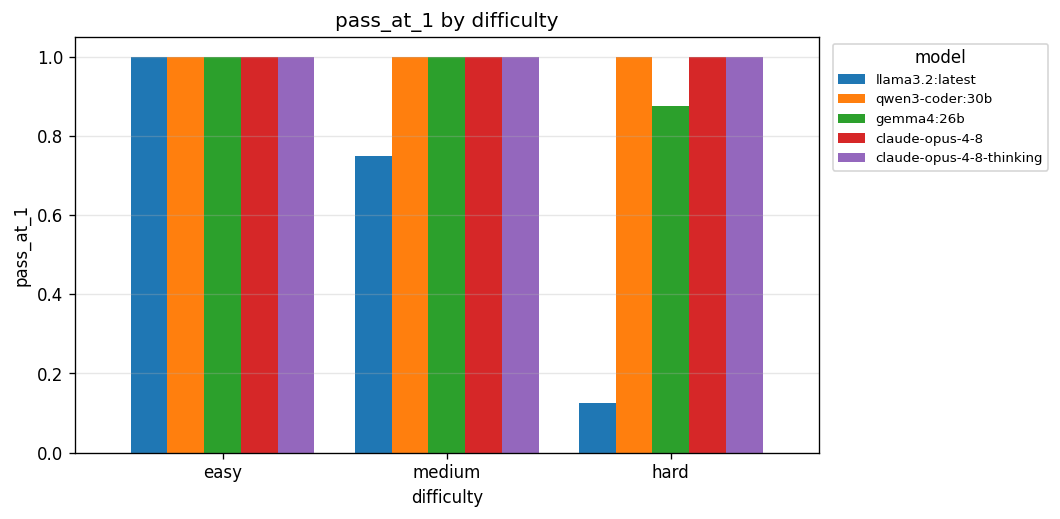

In [25]:
p = FIGURES_DIR / f"{prefix}_passrate_by_difficulty.png"
plots.passrate_by_difficulty(sub, "pass_at_1", p)
plots.show(p)
plt.close("all")

## SQL to Gremlin

### Headline (per model)

In [26]:
display(_headline(df[df["target"] == 'gremlin']))

,validation_pass_rate,pass@1,component_f1,normalized_ted,execution_accuracy,result_f1
model,,,,,,
llama3.2:latest,0.200000,0.200000,0.653274,0.757825,0.000000,0.000000
qwen3-coder:30b,0.733333,0.666667,0.826638,0.608045,0.200000,0.221002
gemma4:26b,1.000000,0.933333,0.909241,0.237387,0.666667,0.767455
claude-opus-4-8,1.000000,1.000000,0.907426,0.347667,0.533333,0.557669
claude-opus-4-8-thinking,1.000000,1.000000,0.905003,0.337021,0.866667,0.887669


### Figures

In [27]:
sub = df[df["target"] == 'gremlin']
label = 'SQL -> Gremlin'
prefix = 'gremlin'

#### Per-model headline metrics

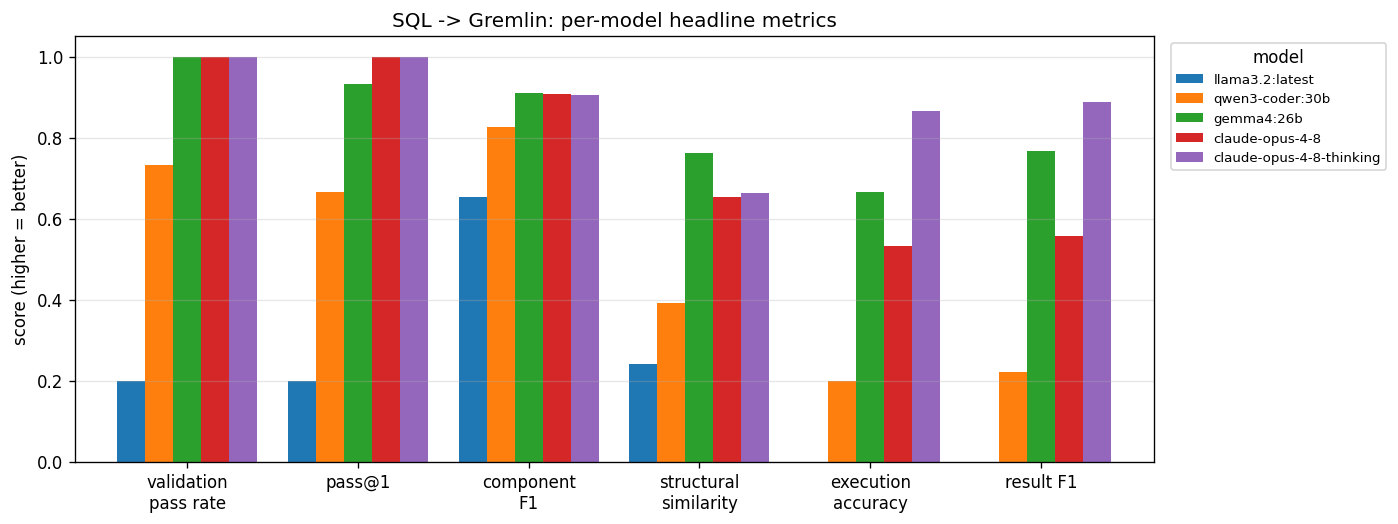

In [28]:
p = FIGURES_DIR / f"{prefix}_model_headline.png"
plots.headline_bars(sub, p, title=f"{label}: per-model headline metrics")
plots.show(p)
plt.close("all")

#### Pass / fail by query x model

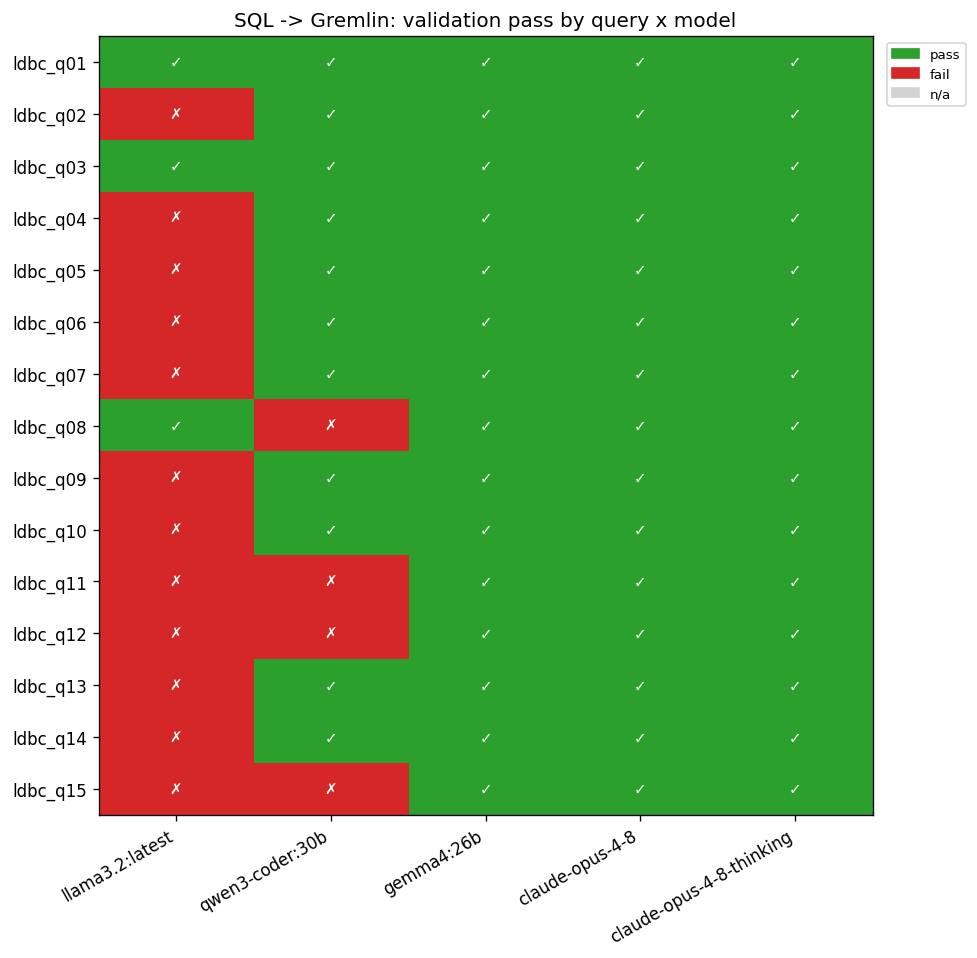

In [29]:
p = FIGURES_DIR / f"{prefix}_query_model_pass.png"
plots.query_model_heatmap(sub, "validation_passed", p, discrete=True, title=f"{label}: validation pass by query x model", cbar_label="pass")
plots.show(p)
plt.close("all")

#### Component F1 by query x model

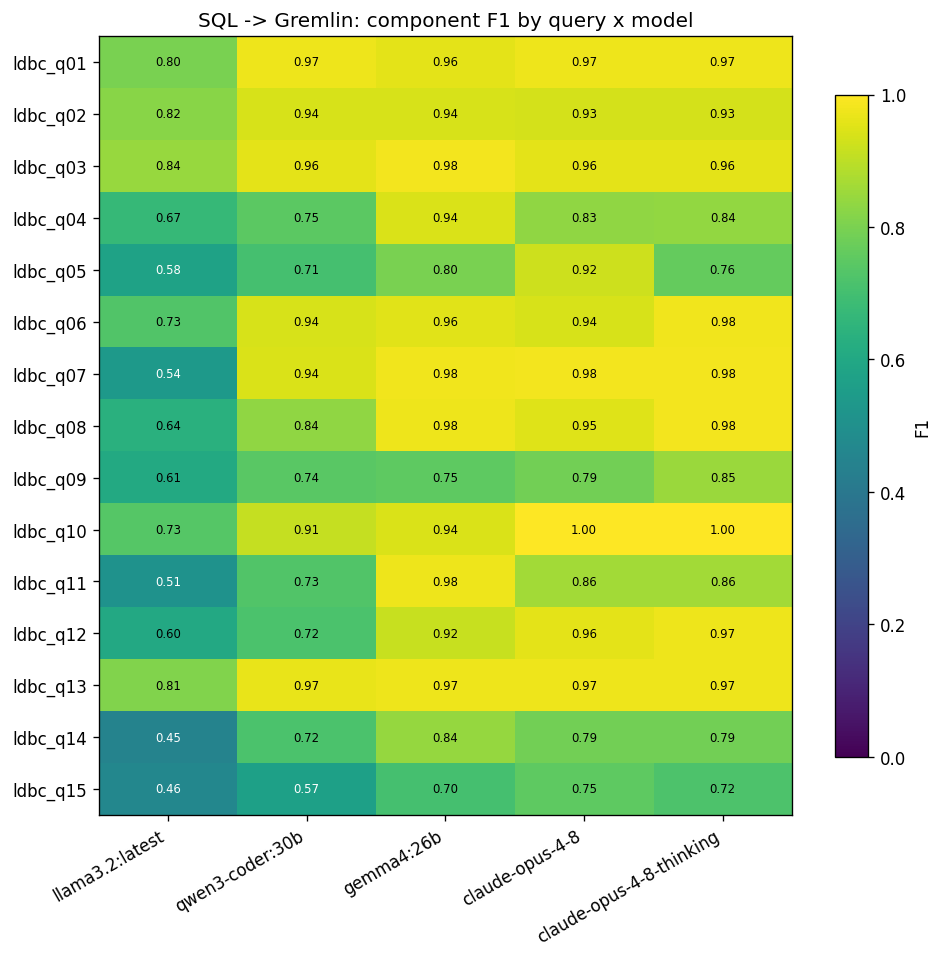

In [30]:
p = FIGURES_DIR / f"{prefix}_query_model_f1.png"
plots.query_model_heatmap(sub, "component_f1_overall", p, title=f"{label}: component F1 by query x model", cbar_label="F1")
plots.show(p)
plt.close("all")

#### Execution accuracy by query x model

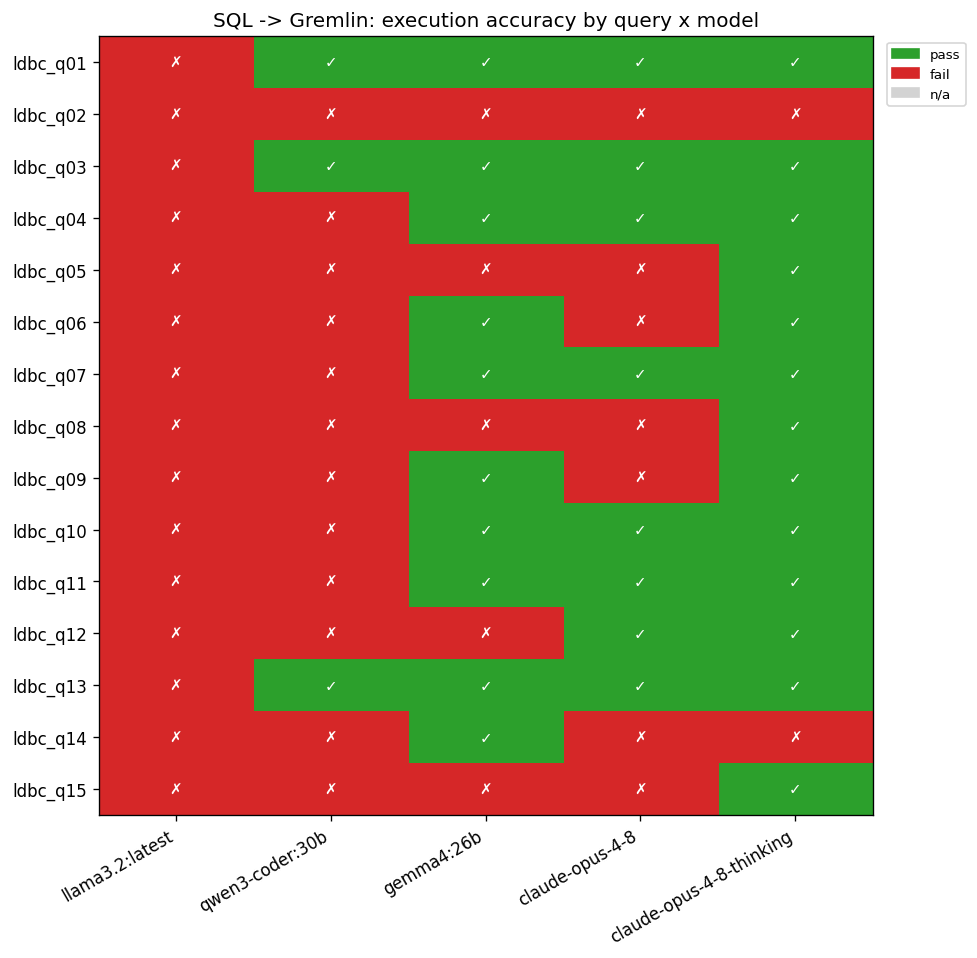

In [31]:
p = FIGURES_DIR / f"{prefix}_query_model_exec.png"
plots.query_model_heatmap(sub, "execution_accuracy", p, discrete=True, title=f"{label}: execution accuracy by query x model", cbar_label="exec acc")
plots.show(p)
plt.close("all")

#### Component F1 per model

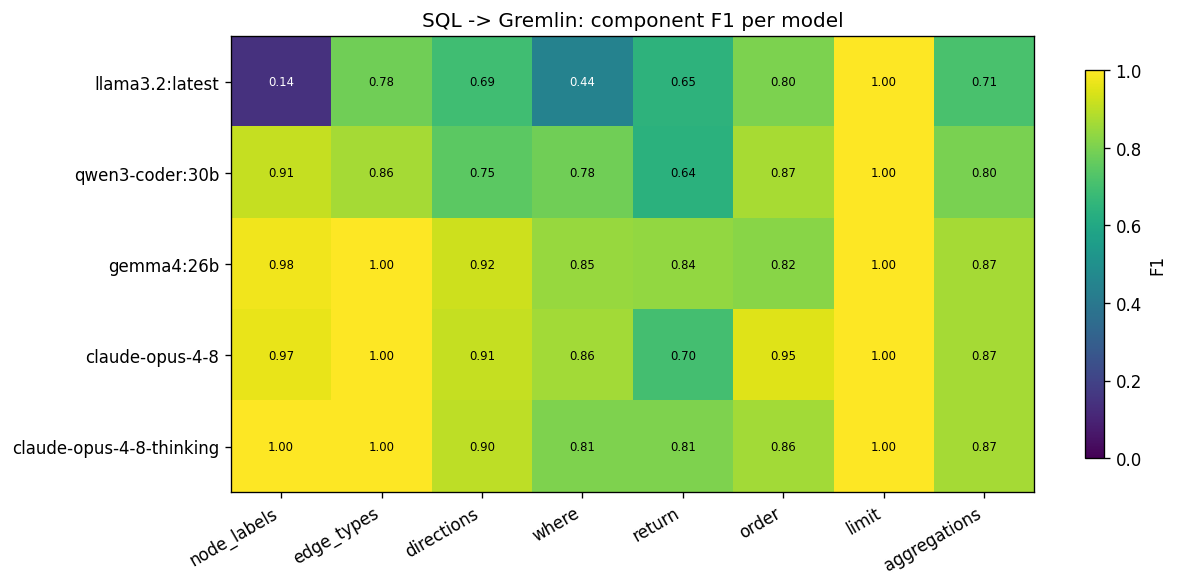

In [32]:
p = FIGURES_DIR / f"{prefix}_component_f1.png"
plots.component_f1_by_model(sub, path=p, title=f"{label}: component F1 per model")
plots.show(p)
plt.close("all")

#### Normalised TED by query x model (lower is better)

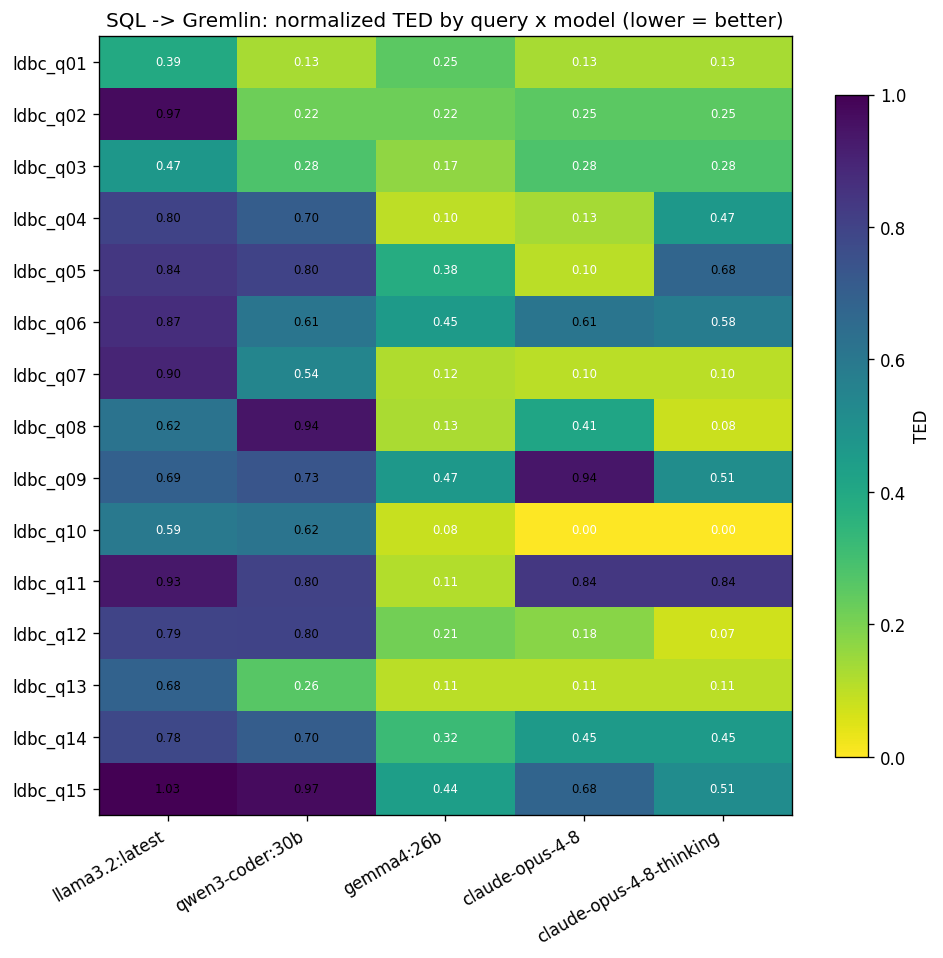

In [33]:
p = FIGURES_DIR / f"{prefix}_query_model_ted.png"
plots.query_model_heatmap(sub, "normalized_ted", p, cmap_name="viridis_r", title=f"{label}: normalized TED by query x model (lower = better)", cbar_label="TED")
plots.show(p)
plt.close("all")

#### Cost and latency per model

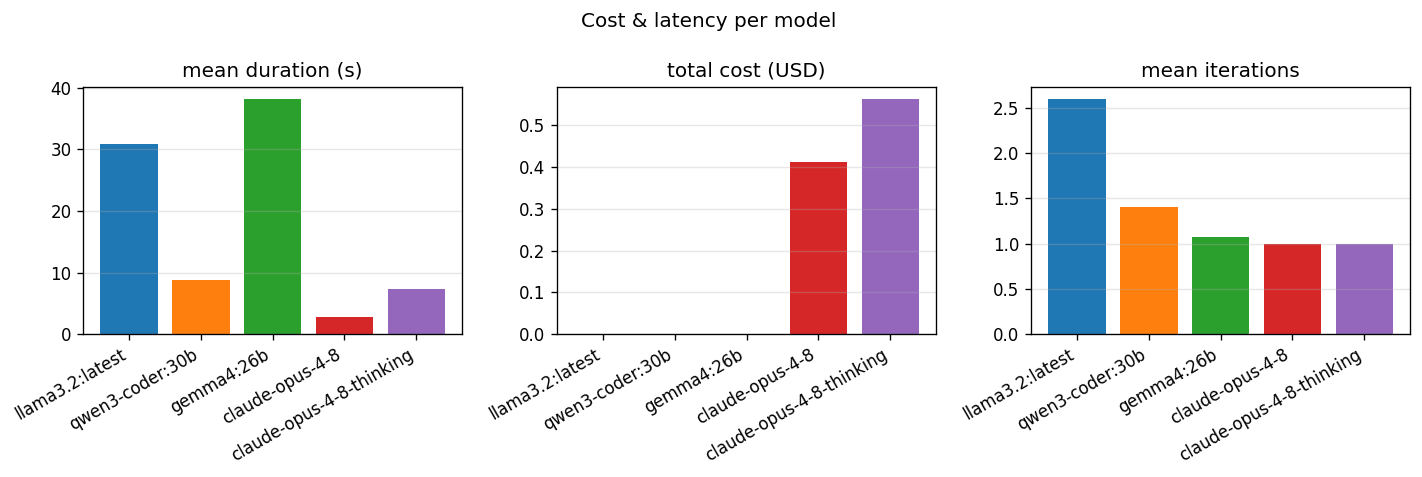

In [34]:
p = FIGURES_DIR / f"{prefix}_cost_latency.png"
plots.cost_latency(sub, p)
plots.show(p)
plt.close("all")

#### Pass@1 by difficulty

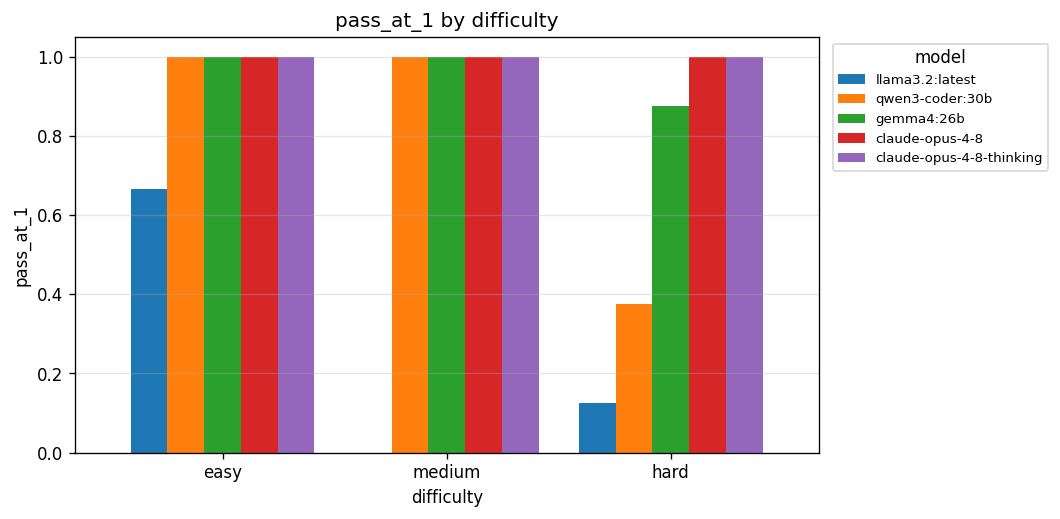

In [35]:
p = FIGURES_DIR / f"{prefix}_passrate_by_difficulty.png"
plots.passrate_by_difficulty(sub, "pass_at_1", p)
plots.show(p)
plt.close("all")

## Headline numbers per matrix cell

In [36]:
group = ["dataset", "target", "model"]
headline = pd.DataFrame()
headline["validation_pass_rate"] = df.groupby(group, observed=True)["validation_passed"].mean()
headline["pass@1"] = df.groupby(group, observed=True)["pass_at_1"].mean()
headline["component_f1"] = df.groupby(group, observed=True)["component_f1_overall"].mean()
headline["normalized_ted"] = df.groupby(group, observed=True)["normalized_ted"].mean()
if HAS_EXEC:
    headline["execution_accuracy"] = df.groupby(group, observed=True)["execution_accuracy"].mean()
    headline["result_f1"] = df.groupby(group, observed=True)["result_f1"].mean()
headline

validation_pass_rate    pass@1  \
dataset target  model                                                      
ldbc    aql     llama3.2:latest                       0.800000  0.466667   
                qwen3-coder:30b                       1.000000  1.000000   
                gemma4:26b                            1.000000  0.933333   
                claude-opus-4-8                       1.000000  1.000000   
                claude-opus-4-8-thinking              1.000000  1.000000   
        cypher  llama3.2:latest                       1.000000  0.866667   
                qwen3-coder:30b                       1.000000  1.000000   
                gemma4:26b                            1.000000  1.000000   
                claude-opus-4-8                       1.000000  1.000000   
                claude-opus-4-8-thinking              1.000000  1.000000   
        gremlin llama3.2:latest                       0.200000  0.200000   
                qwen3-coder:30b                       0.733333  0.666667   
                gemma4:26b                            1.000000  0.933333   
                claude-opus-4-8                       1.000000  1.000000   
                claude-opus-4-8-thinking              1.000000  1.000000   

                                          component_f1  normalized_ted  \
dataset target  model                                                    
ldbc    aql     llama3.2:latest               0.547494        0.414359   
                qwen3-coder:30b               0.821752        0.325791   
                gemma4:26b                    0.875839        0.226171   
                claude-opus-4-8               0.883675        0.224506   
                claude-opus-4-8-thinking      0.901117        0.191370   
        cypher  llama3.2:latest               0.823287        0.404789   
                qwen3-coder:30b               0.925120        0.210969   
                gemma4:26b                    0.981477        0.050576   
                claude-opus-4-8               0.980390        0.066173   
                claude-opus-4-8-thinking      0.971161        0.081915   
        gremlin llama3.2:latest               0.653274        0.757825   
                qwen3-coder:30b               0.826638        0.608045   
                gemma4:26b                    0.909241        0.237387   
                claude-opus-4-8               0.907426        0.347667   
                claude-opus-4-8-thinking      0.905003        0.337021   

                                          execution_accuracy  result_f1  
dataset target  model                                                    
ldbc    aql     llama3.2:latest                     0.000000   0.000000  
                qwen3-coder:30b                     0.466667   0.466667  
                gemma4:26b                          0.933333   0.933333  
                claude-opus-4-8                     0.933333   0.933333  
                claude-opus-4-8-thinking            0.933333   0.933333  
        cypher  llama3.2:latest                     0.200000   0.208120  
                qwen3-coder:30b                     0.533333   0.563676  
                gemma4:26b                          1.000000   1.000000  
                claude-opus-4-8                     1.000000   1.000000  
                claude-opus-4-8-thinking            1.000000   1.000000  
        gremlin llama3.2:latest                     0.000000   0.000000  
                qwen3-coder:30b                     0.200000   0.221002  
                gemma4:26b                          0.666667   0.767455  
                claude-opus-4-8                     0.533333   0.557669  
                claude-opus-4-8-thinking            0.866667   0.887669

## Stratified tables

In [37]:
print("By target x difficulty:")
_bd = df.copy()
_bd["difficulty"] = pd.Categorical(_bd["difficulty"], ["easy", "medium", "hard"], ordered=True)
display(_bd.groupby(["target", "difficulty"], observed=True)[PRIMARY].mean())
print("By target x SQL feature:")
display(frames.by_feature(df, PRIMARY, FEATURES))

By target x difficulty:


validation_passed  pass_at_1  component_f1_overall  \
target  difficulty                                                       
aql     easy                 1.000000   1.000000              0.947789   
        medium               0.950000   0.950000              0.842271   
        hard                 0.950000   0.800000              0.734647   
cypher  easy                 1.000000   0.933333              0.956692   
        medium               1.000000   1.000000              0.936118   
        hard                 1.000000   0.975000              0.928720   
gremlin easy                 0.933333   0.933333              0.929569   
        medium               0.800000   0.800000              0.814686   
        hard                 0.725000   0.675000              0.819661   

                    normalized_ted  execution_accuracy  result_f1  
target  difficulty                                                 
aql     easy              0.041440            0.800000   0.800000  
        medium            0.291636            0.650000   0.650000  
        hard              0.356966            0.600000   0.600000  
cypher  easy              0.086894            0.866667   0.866667  
        medium            0.205999            0.650000   0.650000  
        hard              0.169823            0.750000   0.764423  
gremlin easy              0.294086            0.533333   0.617342  
        medium            0.547702            0.400000   0.400000  
        hard              0.473846            0.450000   0.481170

By target x SQL feature:


validation_passed  pass_at_1  component_f1_overall  \
target  feature                                                           
aql     aggregation           1.000000   0.840000              0.777751   
        cte                   0.800000   0.800000              0.468397   
        distinct              0.900000   0.700000              0.794022   
        join                  0.945455   0.836364              0.771239   
        order_limit           0.933333   0.800000              0.703717   
        subquery              1.000000   0.900000              0.747660   
        temporal              1.000000   1.000000              0.919360   
        union                 0.866667   0.800000              0.668454   
cypher  aggregation           1.000000   1.000000              0.922210   
        cte                   1.000000   1.000000              0.965909   
        distinct              1.000000   0.900000              0.906034   
        join                  1.000000   0.981818              0.925038   
        order_limit           1.000000   1.000000              0.923570   
        subquery              1.000000   1.000000              0.884921   
        temporal              1.000000   0.900000              0.929881   
        union                 1.000000   1.000000              0.876866   
gremlin aggregation           0.760000   0.720000              0.796366   
        cte                   0.600000   0.600000              0.641088   
        distinct              0.700000   0.600000              0.855222   
        join                  0.745455   0.709091              0.806927   
        order_limit           0.733333   0.700000              0.775900   
        subquery              0.800000   0.800000              0.846907   
        temporal              0.800000   0.800000              0.899419   
        union                 0.666667   0.600000              0.743015   

                     normalized_ted  execution_accuracy  result_f1  
target  feature                                                     
aql     aggregation        0.360246            0.680000   0.680000  
        cte                0.457655            0.600000   0.600000  
        distinct           0.348822            0.300000   0.300000  
        join               0.341290            0.600000   0.600000  
        order_limit        0.382555            0.666667   0.666667  
        subquery           0.334407            0.700000   0.700000  
        temporal           0.112562            0.700000   0.700000  
        union              0.400644            0.400000   0.400000  
cypher  aggregation        0.180850            0.720000   0.729744  
        cte                0.224823            0.600000   0.666667  
        distinct           0.214179            0.700000   0.700000  
        join               0.197347            0.690909   0.701399  
        order_limit        0.194596            0.700000   0.719231  
        subquery           0.215560            0.800000   0.800000  
        temporal           0.174185            0.800000   0.800000  
        union              0.295439            0.600000   0.622222  
gremlin aggregation        0.501631            0.440000   0.444000  
        cte                0.725604            0.200000   0.200000  
        distinct           0.424076            0.300000   0.414680  
        join               0.520855            0.400000   0.422669  
        order_limit        0.559767            0.433333   0.436667  
        subquery           0.405774            0.500000   0.510000  
        temporal           0.367279            0.300000   0.426013  
        union              0.565686            0.266667   0.339964

## Failure list for manual error-taxonomy annotation

In [38]:
failure_mask = ~df["validation_passed"].astype(bool)
if HAS_EXEC:
    failure_mask = failure_mask | (df["execution_accuracy"].fillna(1.0) < 1.0)
fcols = ["dataset", "target", "model", "query_id", "difficulty", "validation_passed",
         "component_f1_overall", "normalized_ted"]
failures = df[failure_mask][fcols].copy()
failures["category"] = ""
failures["notes"] = ""
failures = failures.sort_values(["target", "query_id", "model"]).reset_index(drop=True)
print(f"{len(failures)} failure cases to classify.")
failures.head(20)

86 failure cases to classify.


,dataset,target,model,query_id,difficulty,validation_passed,component_f1_overall,normalized_ted,category,notes
0,ldbc,aql,llama3.2:latest,ldbc_q01,easy,True,0.875000,0.023256,,
1,ldbc,aql,llama3.2:latest,ldbc_q02,easy,True,0.625000,0.076923,,
2,ldbc,aql,llama3.2:latest,ldbc_q03,easy,True,0.850000,0.064516,,
3,ldbc,aql,llama3.2:latest,ldbc_q04,hard,True,0.537500,0.392157,,
4,ldbc,aql,qwen3-coder:30b,ldbc_q04,hard,True,0.725379,0.645161,,
5,ldbc,aql,llama3.2:latest,ldbc_q05,hard,True,0.454246,0.544118,,
6,ldbc,aql,qwen3-coder:30b,ldbc_q05,hard,True,0.618659,0.542857,,
7,ldbc,aql,llama3.2:latest,ldbc_q06,medium,True,0.679487,0.436364,,
8,ldbc,aql,llama3.2:latest,ldbc_q07,medium,True,0.834135,0.342466,,
9,ldbc,aql,qwen3-coder:30b,ldbc_q07,medium,True,0.890476,0.246377,,


## Write the final markdown report

In [39]:
FINAL_REPORT_MD.write_text(
    report.build_final_report(
        df,
        models=MODELS,
        targets=TARGETS,
        has_exec=HAS_EXEC,
        features=FEATURES,
        figures_dir=FIGURES_DIR,
        generated_at=datetime.now().isoformat(timespec="seconds"),
    )
)
print(f"Wrote {FINAL_REPORT_MD}")

Wrote /Users/ivona.obonova/school/sql2graph/sql2graph/eval/reports/final.md


In [40]:
# Preview the report header (everything up to the first per-target section).
print(FINAL_REPORT_MD.read_text().split("\n## SQL ->", 1)[0])

# sql2graph evaluation report

Generated: 2026-07-16T19:27:24

Models under evaluation: **llama3.2:latest, qwen3-coder:30b, gemma4:26b, claude-opus-4-8, claude-opus-4-8-thinking**

Targets: **SQL -> Cypher, SQL -> AQL, SQL -> Gremlin**

Total translations: **225** (206 validated)

Total tokens: **1,118,358** input / **159,325** output, approx **$2.92** USD


Results are reported per target below; targets are never combined in one table or figure.




## Summary

This report is the single artefact the thesis results chapter (chapter 5) is written from: the per-target headline and stratified tables map to its sections, and the figures are embedded there. The headline result to read off the execution columns is the cross-language gap on Gremlin and how far the reasoning configurations (gemma4 and opus-4-8-thinking) recover it.

End of the notebook pipeline. The tables and figures here populate **thesis chapter 5 (Evaluation Results)**; the methodology is **chapter 4**.